In [1]:
import argparse
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    if wavelength < 380 or wavelength > 750:
        return (0.5, 0.5, 0.5)
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 < wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 < wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 < wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 < wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 < wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    return (R, G, B)

def scatter_colored(df, col_Es1, col_f, title, xlab, ylab, xlim=None, out_pdf=None):
    d = df.dropna(subset=[col_Es1, col_f]).copy()
    if d.empty:
        return
    lam = 1239.841984 / d[col_Es1].values  # eV -> nm
    colors = [wavelength_to_rgb(w) for w in lam]
    fig, ax = plt.subplots( dpi=90)
    ax.scatter(d[col_Es1], d[col_f], c=colors, s=10)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if xlim is not None:
        ax.set_xlim(*xlim)
    fig.tight_layout()
    if out_pdf is not None:
        fig.savefig(out_pdf, format="pdf")
    return fig, ax

In [2]:
BINS = dict(
    strength=np.array(
        [
            0.00000000e00,
            5.52315881e-04,
            4.80000000e-03,
            3.05000000e-02,
            3.21600000e-01,
            5.79904384e00,
        ],
        dtype=float,
    ),
    absorption=np.array(
        [0.049, 2.7575, 3.0675, 3.3489, 3.671, 12.796],
        dtype=float,
    ),
    splitting=np.array(
        [1.14075568, 6.20877618, 6.56544554, 6.92625786, 7.35424152, 42.863594],
        dtype=float,
    ),
)

In [ ]:
td_dft_path = "../../results/validation/td-dft/VEE_wb97x-D3.csv"
td_dft_df = pd.read_csv(td_dft_path)

td_dft_df

,mol,smiles,E_S1(eV),wl_S1(nm),osc_S1,E_S2(eV),wl_S2(nm),osc_S2,E_S3(eV),wl_S3(nm),...,osc_S1_SOC,E_S2_SOC(eV),wl_S2_SOC(nm),osc_S2_SOC,E_S3_SOC(eV),wl_S3_SOC(nm),osc_S3_SOC,HOMO(eV),LUMO(eV),Gap(eV)
0,mol0001,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,3.484232,355.8,1.555150,4.671025,265.4,0.004173,5.032897,246.3,...,1.555150,4.671025,265.4,0.004173,5.032898,246.3,0.000104,-7.7595,-0.7950,6.96
1,mol0004,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,3.921178,316.2,0.221071,4.145382,299.1,0.280226,4.472756,277.2,...,0.221071,4.145382,299.1,0.280226,4.472756,277.2,0.337075,-6.7767,1.0679,7.84
2,mol0005,Cc1cc(-c2ccccc2)c2ccccc2c1,4.597870,269.7,0.076768,4.721513,262.6,0.280983,5.423316,228.6,...,0.076768,4.721513,262.6,0.280983,5.423316,228.6,0.002020,-7.9701,0.5248,8.49
3,mol0006,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,4.148900,298.8,0.047076,4.192487,295.7,0.048159,4.373187,283.5,...,0.047076,4.192487,295.7,0.048159,4.373187,283.5,0.034729,-7.1452,0.3776,7.52
4,mol0007,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,4.536639,273.3,0.007779,4.555223,272.2,0.019595,4.620552,268.3,...,0.007779,4.555223,272.2,0.019595,4.620552,268.3,0.002269,-7.2822,0.4573,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,mol1785,COC(=O)c1ccc(C)cc1,5.236681,236.8,0.014326,5.453252,227.4,0.000490,5.600300,221.4,...,0.014326,5.453255,227.4,0.000490,5.600300,221.4,0.532561,-9.2307,0.5082,9.74
454,mol1787,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,5.145753,240.9,0.027909,5.467144,226.8,0.271576,5.673112,218.5,...,0.027909,5.467144,226.8,0.271577,5.673114,218.5,0.017089,-8.2088,1.4654,9.67
455,mol1793,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,1.670407,742.2,0.010177,3.337971,371.4,0.750232,4.090485,303.1,...,0.010177,3.337971,371.4,0.750232,4.090486,303.1,0.000009,-7.8016,-1.6275,6.17
456,mol1795,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,2.288210,541.8,0.040712,3.647002,340.0,0.469434,3.925125,315.9,...,0.040712,3.647002,340.0,0.469434,3.925125,315.9,0.621733,-7.9761,-1.7586,6.22


In [8]:
std2_path = "../../results/validation/std2/std2.csv"
std2_df = pd.read_csv(std2_path)

std2_df

,partition,mol,smiles,strength,absorption,E_S1_eV,E_T1_eV,E_ST_eV,f_osc_S1,token
0,partition_0,mol0001,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,0,0,3.1183,2.0336,1.0847,1.762547,str_0_abs_0
1,partition_0,mol0004,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,0,0,3.0243,2.6489,0.3754,0.115084,str_0_abs_0
2,partition_0,mol0005,Cc1cc(-c2ccccc2)c2ccccc2c1,0,0,4.1843,3.3440,0.8403,0.005298,str_0_abs_0
3,partition_0,mol0006,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,0,0,3.2248,2.8290,0.3958,0.010807,str_0_abs_0
4,partition_0,mol0007,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,0,0,3.9926,3.4429,0.5497,0.072529,str_0_abs_0
...,...,...,...,...,...,...,...,...,...,...
495,partition_1,mol1785,COC(=O)c1ccc(C)cc1,4,4,4.6919,4.2582,0.4337,0.017268,str_4_abs_4
496,partition_1,mol1787,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,4,4,4.4436,4.0198,0.4238,0.026054,str_4_abs_4
497,partition_1,mol1793,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,4,4,0.6178,0.2721,0.3457,0.001917,str_4_abs_4
498,partition_1,mol1795,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,4,4,1.3097,0.9405,0.3692,0.018054,str_4_abs_4


In [7]:
td_dft_df.columns

Index(['mol', 'smiles', 'E_S1(eV)', 'wl_S1(nm)', 'osc_S1', 'E_S2(eV)',
       'wl_S2(nm)', 'osc_S2', 'E_S3(eV)', 'wl_S3(nm)', 'osc_S3', 'E_T1(eV)',
       'E_T2(eV)', 'E(S1-T1)(eV)', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)',
       'osc_S1_SOC', 'E_S2_SOC(eV)', 'wl_S2_SOC(nm)', 'osc_S2_SOC',
       'E_S3_SOC(eV)', 'wl_S3_SOC(nm)', 'osc_S3_SOC', 'HOMO(eV)', 'LUMO(eV)',
       'Gap(eV)'],
      dtype='object')

In [12]:
len(td_dft_df)

458

In [9]:
std2_df.columns

Index(['partition', 'mol', 'smiles', 'strength', 'absorption', 'E_S1_eV',
       'E_T1_eV', 'E_ST_eV', 'f_osc_S1', 'token'],
      dtype='object')

In [31]:
td_dft_precond = td_dft_df[
    ['mol', 'smiles', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)', 'osc_S1_SOC' , ]]
td_dft_precond = td_dft_precond.rename(columns={
    'E_S1_SOC(eV)': 'td_dft_E_S1_eV',
    'wl_S1_SOC(nm)': 'td_dft_wl_S1_nm',
    'osc_S1_SOC': 'td_dft_osc_S1',
})

std2_precond = std2_df[['mol', 'smiles', 'strength', 'absorption','token']]
std2_precond = std2_precond.rename(columns={
    'strength': 'precond_strength_token',
    'absorption': 'precond_absorption_token',
    'token': 'precond_token',
})

merged_df = pd.merge(td_dft_precond, std2_precond, on=['mol', 'smiles'])
merged_df


,mol,smiles,td_dft_E_S1_eV,td_dft_wl_S1_nm,td_dft_osc_S1,precond_strength_token,precond_absorption_token,precond_token
0,mol0001,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,3.484232,355.8,1.555150,0,0,str_0_abs_0
1,mol0004,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,3.921178,316.2,0.221071,0,0,str_0_abs_0
2,mol0005,Cc1cc(-c2ccccc2)c2ccccc2c1,4.597870,269.7,0.076768,0,0,str_0_abs_0
3,mol0006,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,4.148900,298.8,0.047076,0,0,str_0_abs_0
4,mol0007,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,4.536639,273.3,0.007779,0,0,str_0_abs_0
...,...,...,...,...,...,...,...,...
453,mol1785,COC(=O)c1ccc(C)cc1,5.236681,236.8,0.014326,4,4,str_4_abs_4
454,mol1787,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,5.145753,240.9,0.027909,4,4,str_4_abs_4
455,mol1793,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,1.670407,742.2,0.010177,4,4,str_4_abs_4
456,mol1795,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,2.288210,541.8,0.040712,4,4,str_4_abs_4


In [33]:
merged_df['precond_strength_token'].unique()

array([0, 1, 2, 3, 4])

In [34]:
# bin the td-dft values into tokens from 0 to 4 based on BINS

td_dft_strength_l = merged_df['td_dft_osc_S1'].to_list()
td_dft_strength_token_l = []

for strength in td_dft_strength_l:
    token = np.where(BINS['strength'] < strength)[0][-1]
    td_dft_strength_token_l.append(token)

td_dft_absorption_l = merged_df['td_dft_E_S1_eV'].to_list()
td_dft_absorption_token_l = []

for absorption in td_dft_absorption_l:
    token = np.where(BINS['absorption'] < absorption)[0][-1]
    td_dft_absorption_token_l.append(token)

merged_df['td_dft_strength_token'] = td_dft_strength_token_l
merged_df['td_dft_absorption_token'] = td_dft_absorption_token_l

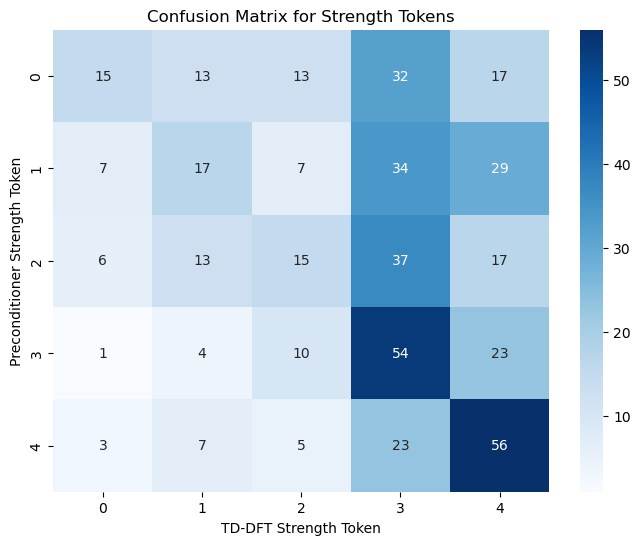

In [36]:
# create a confusion matrix for strength tokens
confusion_strength = pd.crosstab(
    merged_df['precond_strength_token'],
    merged_df['td_dft_strength_token'],
    rownames=['Preconditioner Strength Token'],
    colnames=['TD-DFT Strength Token'],
)   
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_strength, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Strength Tokens')
plt.show()

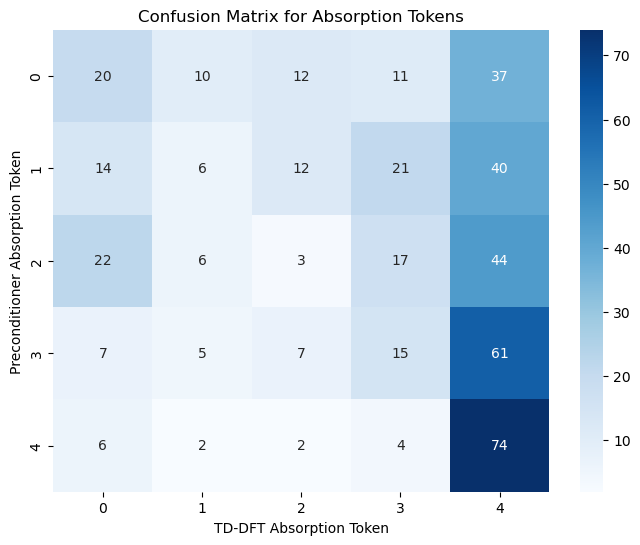

In [37]:
# create a confusion matrix for absorption tokens
confusion_absorption = pd.crosstab(
    merged_df['precond_absorption_token'],
    merged_df['td_dft_absorption_token'],
    rownames=['Preconditioner Absorption Token'],
    colnames=['TD-DFT Absorption Token'],
)   
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_absorption, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Absorption Tokens')
plt.show()

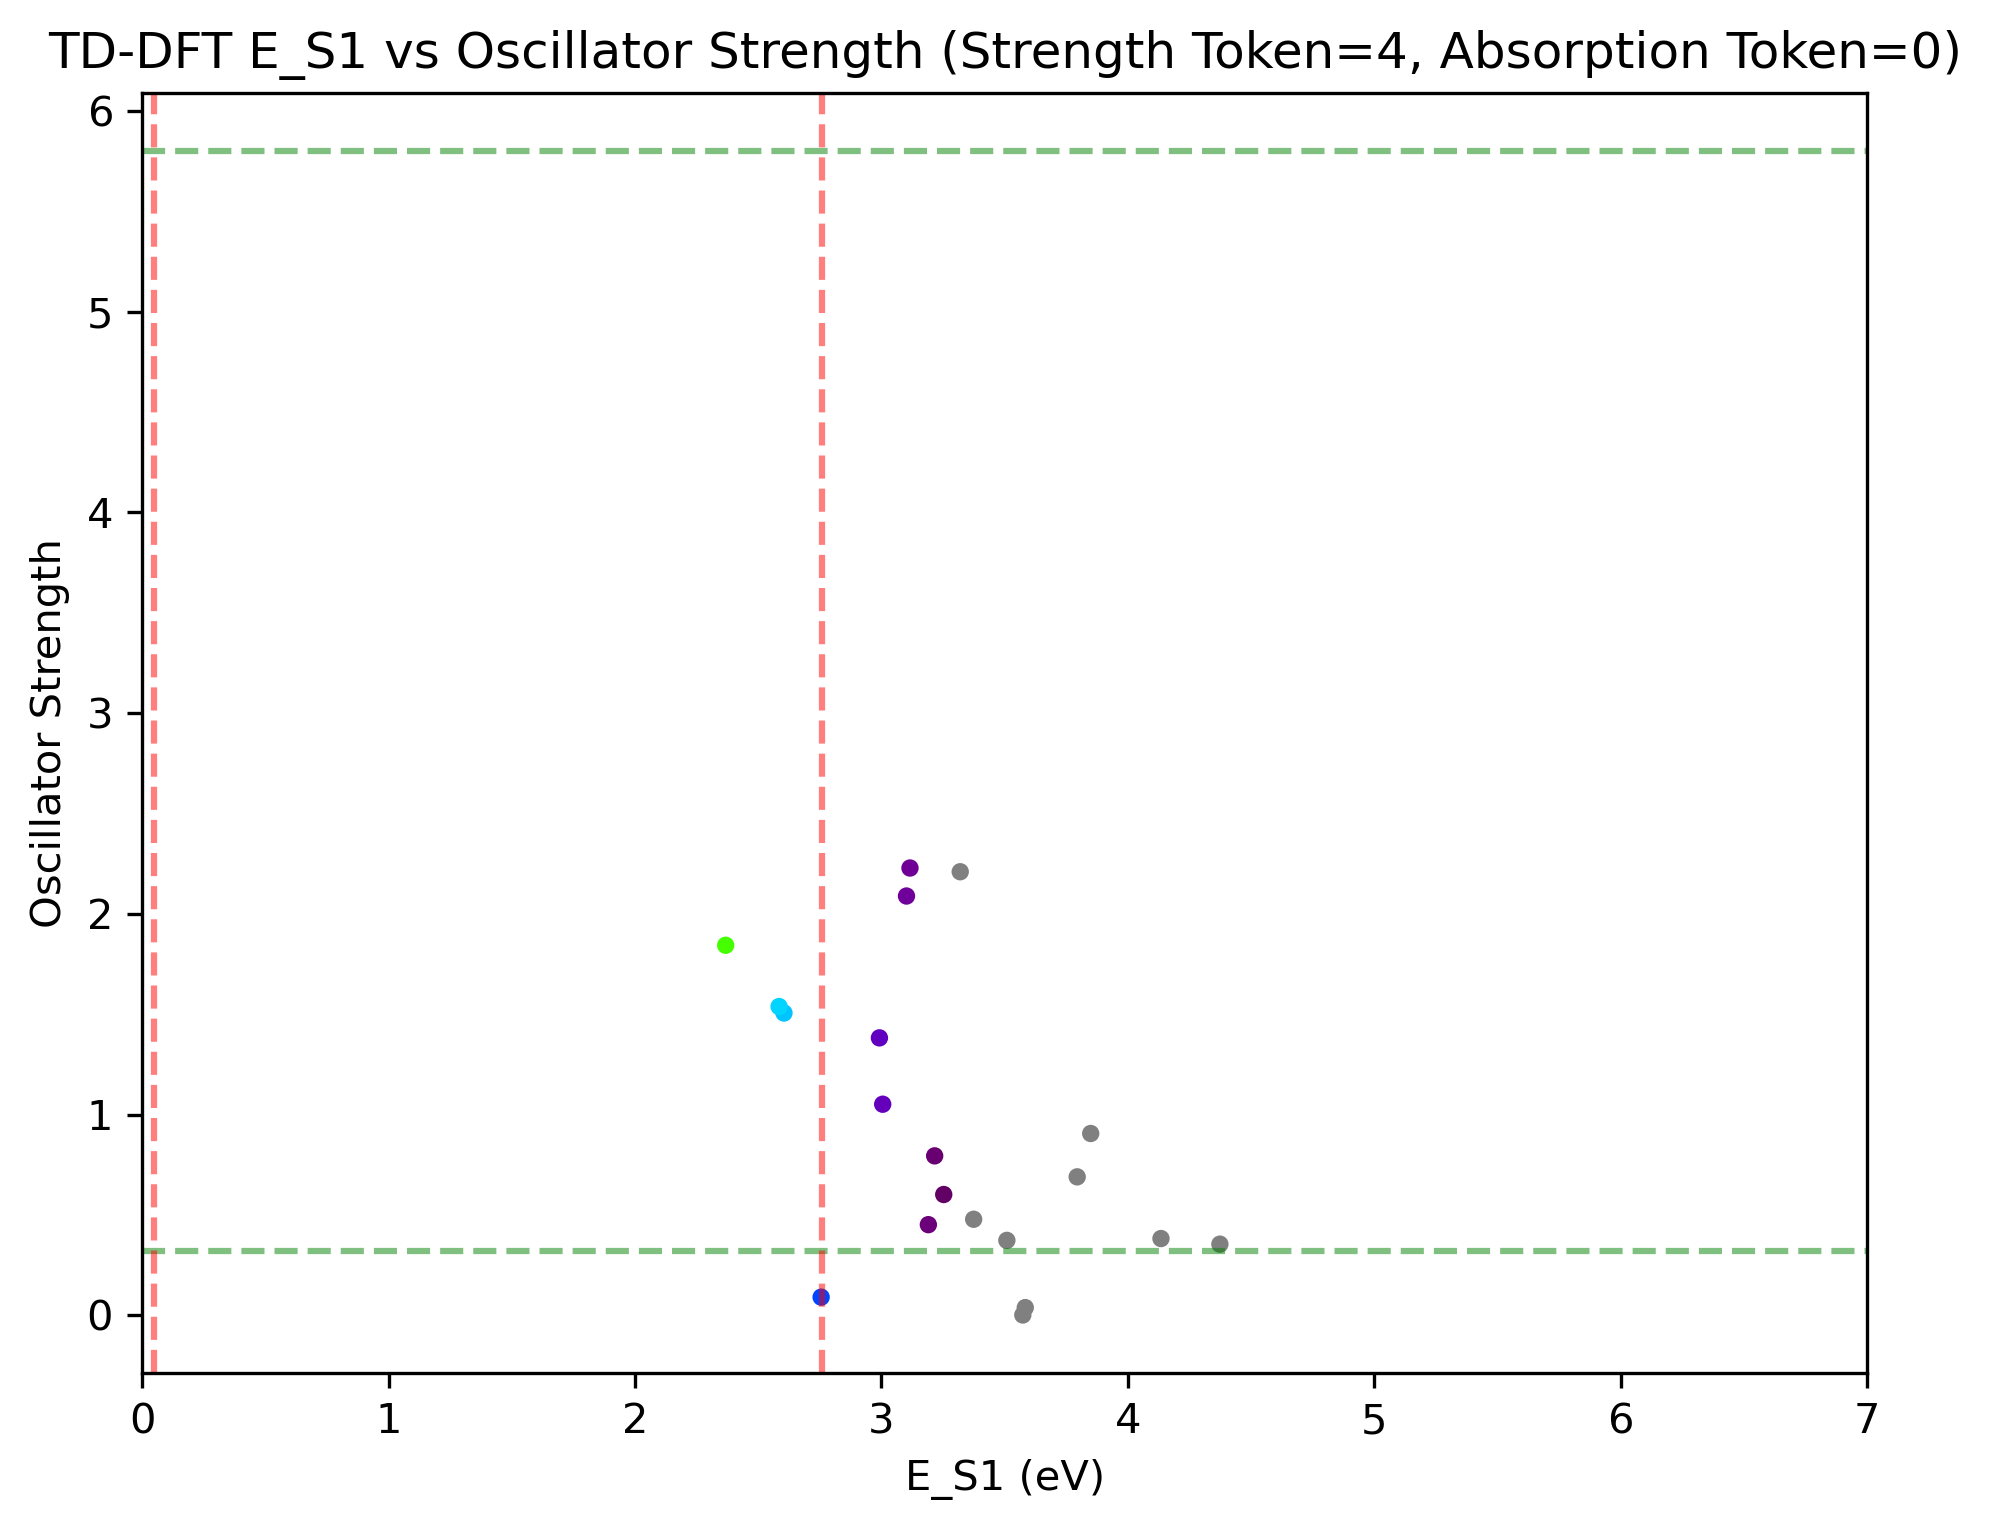

In [51]:
# for subset strength token = 4, absorption token = 0
selected_strength_token = 4
selected_absorption_token = 0
subset_df = merged_df[
    (merged_df['precond_strength_token'] == selected_strength_token) &
    (merged_df['precond_absorption_token'] == selected_absorption_token)
]

fig, ax = scatter_colored(
    subset_df,
    col_Es1='td_dft_E_S1_eV',
    col_f='td_dft_osc_S1',
    title='TD-DFT E_S1 vs Oscillator Strength (Strength Token=4, Absorption Token=0)',
    xlab='E_S1 (eV)',
    ylab='Oscillator Strength',
    xlim=(0, 7),
)

# plot bin edge of the corresponding token as veritical and horizontal dashed lines
strength_bin_edges = BINS['strength'][selected_strength_token:selected_strength_token+2]
absorption_bin_edges = BINS['absorption'][selected_absorption_token:selected_absorption_token+2]

for y in strength_bin_edges:
    ax.axhline(y=y, color='green', linestyle='--', alpha=0.5)
for x in absorption_bin_edges:
    ax.axvline(x=x, color='red', linestyle='--', alpha=0.5)
plt.show()
plt.close(fig)

In [68]:
BINS['strength']

array([0.00000000e+00, 5.52315881e-04, 4.80000000e-03, 3.05000000e-02,
       3.21600000e-01, 5.79904384e+00])

In [67]:
merged_df['td_dft_osc_S1'].min()

7e-09

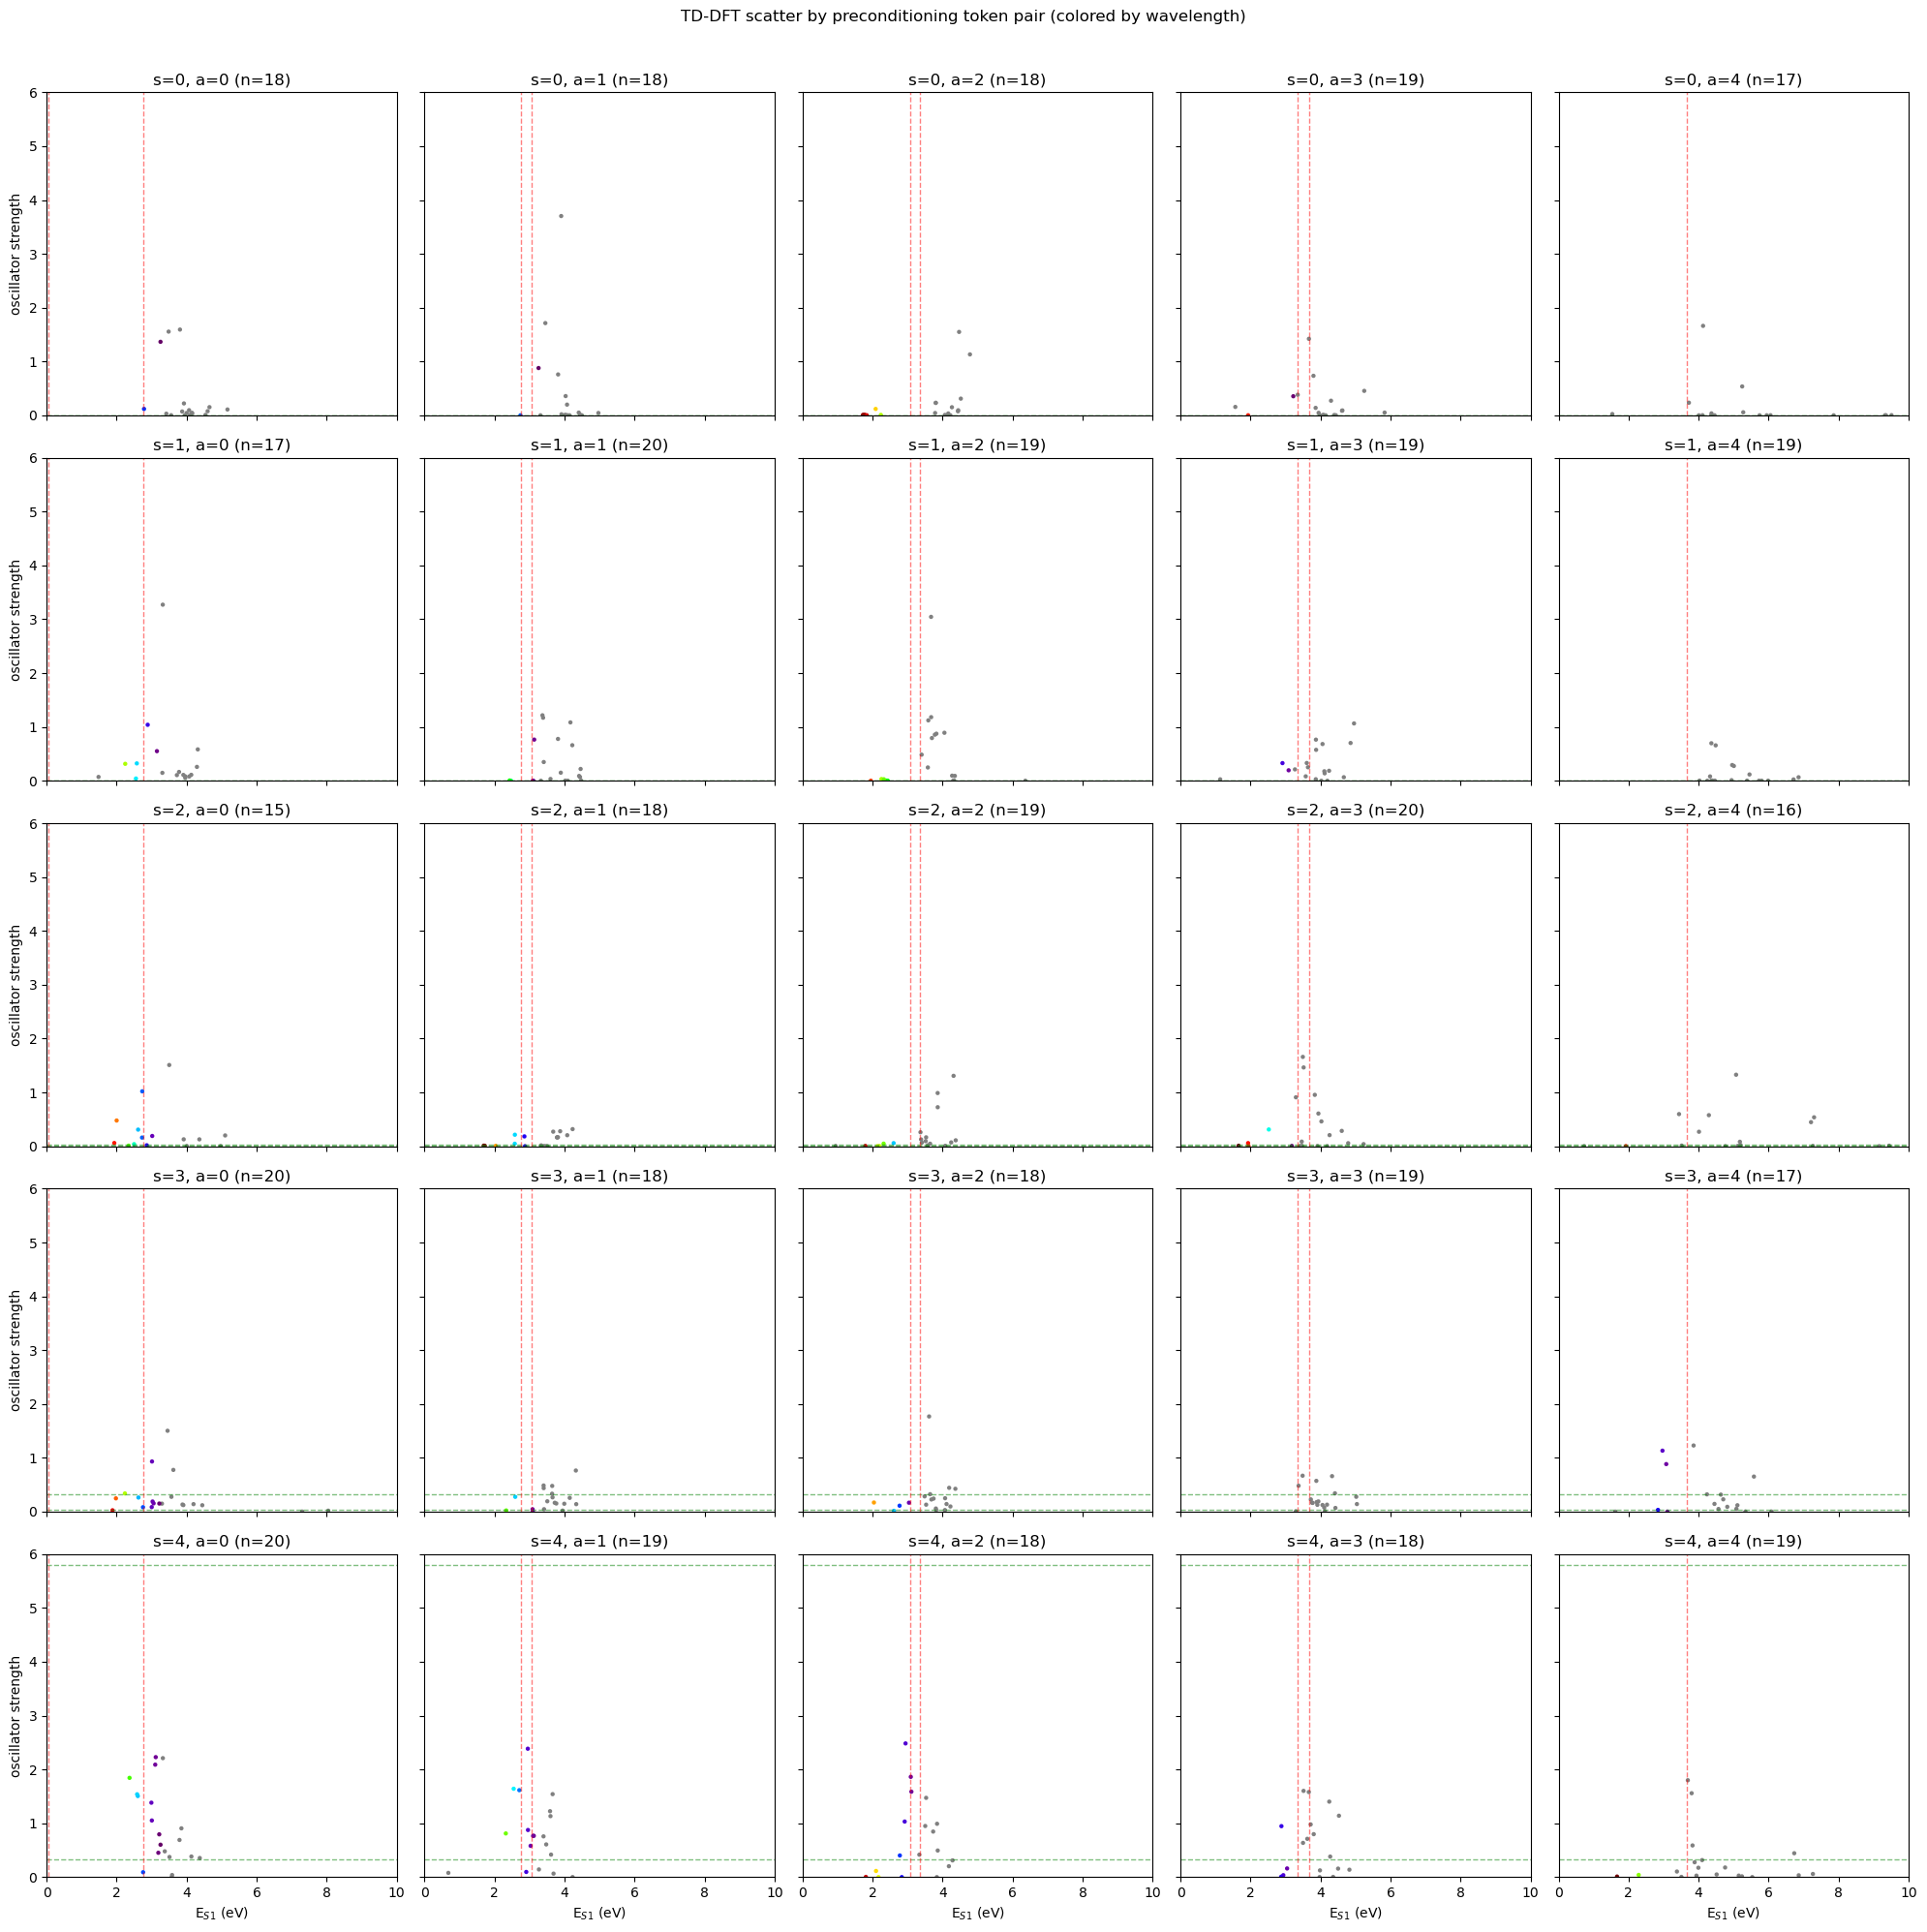

In [69]:
# Joint 5×5 scatter grid for (precond_strength_token=i, precond_absorption_token=j),
# colored by wavelength (from TD-DFT E_S1), using your wavelength_to_rgb() helper.

n_str = 5
n_abs = 5

fig, axes = plt.subplots(n_str, n_abs, figsize=(20, 20), dpi=100, sharex=True, sharey=True)

for i in range(n_str):
    for j in range(n_abs):
        ax = axes[i, j]

        subset_df = merged_df[
            (merged_df["precond_strength_token"] == i)
            & (merged_df["precond_absorption_token"] == j)
        ].copy()

        # Always label axes consistently
        ax.set_xlabel("E$_{S1}$ (eV)")
        ax.set_ylabel("oscillator strength")

        if subset_df.empty:
            ax.set_title(f"s={i}, a={j}\nno data")
            ax.set_xlim(0, 10)
            continue

        # --- color by wavelength (requires E in eV) ---
        d = subset_df.dropna(subset=["td_dft_E_S1_eV", "td_dft_osc_S1"]).copy()
        if d.empty:
            ax.set_title(f"s={i}, a={j}\nno finite TD-DFT")
            ax.set_xlim(0, 10)
            continue

        lam = 1239.841984 / pd.to_numeric(d["td_dft_E_S1_eV"], errors="coerce").to_numpy()
        colors = [wavelength_to_rgb(w) for w in lam]

        ax.scatter(
            d["td_dft_E_S1_eV"],
            d["td_dft_osc_S1"],
            c=colors,
            s=10,
            linewidths=0,
        )

        ax.set_title(f"s={i}, a={j} (n={len(d)})")
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 6)

        # --- bin edges (vertical = absorption/E, horizontal = strength/f) ---
        # strength bins apply to oscillator strength (y-axis)
        y_edges = BINS["strength"][i : i + 2]
        for y in y_edges:
            ax.axhline(y=y, color="green", linestyle="--", alpha=0.5, linewidth=1.0)

        # absorption bins apply to energy (x-axis)
        x_edges = BINS["absorption"][j : j + 2]
        for x in x_edges:
            ax.axvline(x=x, color="red", linestyle="--", alpha=0.5, linewidth=1.0)

# Cosmetic: reduce clutter; keep only outer tick labels
for ax in axes[:-1, :].ravel():
    ax.set_xlabel("")
for ax in axes[:, 1:].ravel():
    ax.set_ylabel("")

fig.suptitle("TD-DFT scatter by preconditioning token pair (colored by wavelength)", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()
